# S&P 500 动量因子选股 v2

**目标**: 用纯量价动量特征 + LightGBM 在 S&P 500 中预测未来 10 天残差收益率，选出 top 10 股票等权持有。

**v1 → v2 改动**:
- 特征从 39 个冗余指标 → 18 个，分 4 组（基础动量、skip 动量、路径质量、风险调整动量）
- 去掉 sector neutralize + rank 双重变换，只做一次 cross-sectional rank
- 标签用原始残差收益（不 rank），让模型学真实分布
- 加入行业作为 categorical feature

**已知偏差**:
- 使用当前 S&P 500 成分股，存在 survivorship bias
- 残差收益用 β-adjusted: `r_stock - β × r_SPY`

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from equity.data import get_sp500_tickers, get_sp500_sectors, download_stock_data, load_universe, load_spy
from equity.features import compute_all_features, cross_sectional_rank
from equity.labels import make_labels
from equity.model import run_cv_pipeline
from equity.backtest import backtest_topN, compute_daily_returns
from equity.analysis import (
    summary_metrics, print_metrics,
    calc_ic_series, quantile_analysis,
    plot_equity_curve, plot_ic_analysis, plot_quantile_returns, plot_feature_importance,
)

pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. 数据下载

下载 S&P 500 全部成分股 + SPY 的日线 OHLCV（2015-2026）。首次运行需要几分钟，之后从 parquet 缓存加载。

In [2]:
tickers = get_sp500_tickers()
print(f"S&P 500 tickers: {len(tickers)}")
print(f"Sample: {tickers[:10]}")

download_stock_data(tickers, start="2015-01-01", end="2026-04-01", cache_dir="../data/equity")

S&P 500 tickers: 503
Sample: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM']
All 504 tickers already cached.


In [3]:
# 加载数据
panel = load_universe(cache_dir="../data/equity", min_history_days=252)
spy = load_spy(cache_dir="../data/equity")

n_stocks = panel.index.get_level_values("ticker").nunique()
date_range = panel.index.get_level_values("date")
print(f"Universe: {n_stocks} stocks")
print(f"Date range: {date_range.min().date()} to {date_range.max().date()}")
print(f"Total rows: {len(panel):,}")
print(f"\nSPY: {len(spy)} days")
print(f"\nSample:")
panel.head()

Universe: 502 stocks
Date range: 2015-01-02 to 2026-03-31
Total rows: 1,375,458

SPY: 2827 days

Sample:


Price                   open       high        low      close       volume
date       ticker                                                         
2015-01-02 A       37.535488  37.653983  36.797173  36.970360    1529200.0
           AAPL    24.671145  24.682220  23.776348  24.214888  212818400.0
           ABBV    41.470293  42.078659  41.470293  41.755463    5086100.0
           ABT     36.517570  36.678974  36.025289  36.235115    3216600.0
           ACGL    18.764398  18.884845  18.472788  18.539352    1101600.0

## 2. 特征工程

4 组 ~18 个特征，每组对应一个独立假说：
1. **基础动量** (5): 不同窗口的过去收益 — 谁最近更强
2. **Skip 动量** (3): 去掉近期反转噪音 — 可延续的趋势
3. **路径质量** (6): 效率比、涨跌天数、收益集中度、回撤 — 动量是平滑还是乱冲
4. **风险调整动量** (4): return/vol、slope/RMSE — 单位风险下的强度

变换：只做一次 cross-sectional rank（不叠加 sector neutralize）。
行业信息作为 categorical feature 交给模型。

In [4]:
%%time
raw_features = compute_all_features(panel)
print(f"Raw features shape: {raw_features.shape}")
print(f"Feature columns ({len(raw_features.columns)}):")
for i, col in enumerate(raw_features.columns):
    print(f"  {i+1:2d}. {col}")

Raw features shape: (1375458, 18)
Feature columns (18):
   1. ret_5d
   2. ret_10d
   3. ret_20d
   4. ret_60d
   5. ret_120d
   6. skip5_ret_20d
   7. skip5_ret_60d
   8. skip20_ret_120d
   9. efficiency_20d
  10. efficiency_60d
  11. up_ratio_20d
  12. ret_concentration_20d
  13. max_dd_20d
  14. dist_high_60d
  15. ret_vol_20d
  16. ret_vol_60d
  17. slope_rmse_20d
  18. slope_rmse_60d
CPU times: user 31.1 s, sys: 140 ms, total: 31.2 s
Wall time: 31.2 s


In [5]:
%%time
# Cross-sectional rank only (no sector neutralization)
features = cross_sectional_rank(raw_features)

# Add sector as categorical feature
sector_map = get_sp500_sectors()
tickers = features.index.get_level_values("ticker")
sectors = tickers.map(sector_map)
# Encode sector as integer category
sector_codes, sector_names = pd.factorize(sectors)
features["sector"] = sector_codes

print(f"Ranked features shape: {features.shape}")
print(f"Value range (excl sector): [{features.drop(columns='sector').min().min():.3f}, {features.drop(columns='sector').max().max():.3f}]")
print(f"Sectors: {len(sector_names)} categories")
print(f"\nNaN ratio per feature:")
print((features.isna().sum() / len(features)).describe())

Ranked features shape: (1375458, 19)
Value range (excl sector): [0.002, 1.000]
Sectors: 11 categories

NaN ratio per feature:
count    19.000000
mean      0.014829
std       0.012785
min       0.000000
25%       0.007002
50%       0.007427
75%       0.021898
max       0.043796
dtype: float64
CPU times: user 4 s, sys: 64.1 ms, total: 4.07 s
Wall time: 4.47 s


## 3. 标签构造

未来 10 天 beta-adjusted 残差收益率。

**v2 改动**: 不做 rank 变换，直接用原始残差收益作为回归标签。
v1 把标签 rank 到 [0,1] 后模型预测全部集中在 ~0.5（无区分力）。
原始残差虽然噪音大（std ~5.4%），但保留了收益幅度信息，
让模型可以区分"强 alpha"和"弱 alpha"。

In [6]:
%%time
# Raw beta-adjusted residual return labels (NOT ranked)
labels = make_labels(panel, spy, periods=10, beta_window=252)
print(f"Labels shape: {labels.shape}")
print(f"NaN ratio: {labels.isna().mean():.3f}")
print(f"\nLabel distribution:")
print(labels.dropna().describe())

Labels shape: (1375458,)
NaN ratio: 0.050

Label distribution:
count    1.307186e+06
mean     9.836761e-04
std      5.424368e-02
min     -7.833699e-01
25%     -2.649492e-02
50%      3.064195e-04
75%      2.715335e-02
max      1.781302e+00
Name: label, dtype: float64
CPU times: user 1.06 s, sys: 33 ms, total: 1.09 s
Wall time: 1.09 s


## 4. 单特征 IC 预检

每个特征单独与未来 10 天残差收益的 Spearman 相关（截面 IC）。
用 ranked features vs raw labels，和最终模型输入一致。

In [7]:
from scipy import stats

# Align features and labels (exclude sector from IC check)
momentum_cols = [c for c in features.columns if c != "sector"]
common_idx = features.index.intersection(labels.dropna().index)
feat_aligned = features.loc[common_idx, momentum_cols]
lab_aligned = labels.loc[common_idx]

# Compute mean IC for each feature
feature_ics = {}
for col in feat_aligned.columns:
    valid = feat_aligned[col].notna() & lab_aligned.notna()
    if valid.sum() < 1000:
        continue
    
    ic_daily_data = feat_aligned.loc[valid, [col]].copy()
    ic_daily_data["label"] = lab_aligned.loc[valid]
    
    daily_ic = ic_daily_data.groupby(level="date").apply(
        lambda g: stats.spearmanr(g.iloc[:, 0], g["label"])[0] if len(g) > 10 else np.nan
    )
    feature_ics[col] = {
        "mean_ic": daily_ic.mean(),
        "ic_std": daily_ic.std(),
        "icir": daily_ic.mean() / daily_ic.std() if daily_ic.std() > 0 else 0,
        "pct_positive": (daily_ic > 0).mean(),
    }

ic_df = pd.DataFrame(feature_ics).T.sort_values("mean_ic", ascending=False)
print(f"Feature IC summary ({len(ic_df)} features):\n")
print(ic_df.to_string(float_format="{:.4f}".format))

Feature IC summary (18 features):

                       mean_ic  ic_std    icir  pct_positive
ret_concentration_20d   0.0104  0.1050  0.0992        0.5466
efficiency_60d          0.0073  0.1257  0.0582        0.5452
skip20_ret_120d         0.0034  0.1933  0.0177        0.5258
ret_120d               -0.0005  0.1994 -0.0024        0.5277
efficiency_20d         -0.0072  0.1092 -0.0659        0.4786
up_ratio_20d           -0.0094  0.1252 -0.0753        0.4849
slope_rmse_20d         -0.0119  0.1548 -0.0766        0.4946
dist_high_60d          -0.0122  0.1779 -0.0688        0.4928
max_dd_20d             -0.0123  0.1659 -0.0740        0.4835
skip5_ret_20d          -0.0125  0.1588 -0.0786        0.4790
ret_10d                -0.0133  0.1602 -0.0829        0.4820
skip5_ret_60d          -0.0147  0.1787 -0.0824        0.4779
slope_rmse_60d         -0.0152  0.1750 -0.0870        0.4712
ret_5d                 -0.0153  0.1608 -0.0951        0.4653
ret_vol_20d            -0.0159  0.1564 -0.1017    

## 5. 模型训练 — LightGBM + Purged CV

v2 改动：
- 标签直接用原始残差收益（不 rank）
- sector 列作为 categorical feature
- 更保守的参数（更浅的树、更强正则）

In [8]:
%%time
predictions, models = run_cv_pipeline(
    features=features,
    labels=labels,         # raw residual return (not ranked)
    raw_labels=labels,     # same — evaluation uses same raw labels
    n_splits=5,
    train_days=500,
    test_days=60,
    purge_days=10,
    embargo_days=5,
    categorical_features=["sector"],
)
print(f"\nOOS predictions: {len(predictions):,} samples")
print(f"Date range: {predictions.index.get_level_values('date').min().date()} "
      f"to {predictions.index.get_level_values('date').max().date()}")
print(f"\nPrediction distribution:")
print(predictions["prediction"].describe())
predictions.head()

Fold 1/5: train 2015-07-06→2017-06-27 (233205 samples), test 2017-07-20→2017-10-12 (28423 samples)
LightGBM cuda unavailable, falling back: CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1
LightGBM gpu unavailable, falling back: No OpenCL device found
Training until validation scores don't improve for 50 rounds


[LightGBM] [Fatal] CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1


Early stopping, best iteration is:
[1]	valid_0's l2: 0.0016357
LightGBM device: cpu
Fold 2/5: train 2017-08-09→2019-08-05 (238240 samples), test 2019-08-27→2019-11-19 (28895 samples)
LightGBM cuda unavailable, falling back: CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1
LightGBM gpu unavailable, falling back: No OpenCL device found
Training until validation scores don't improve for 50 rounds


[LightGBM] [Fatal] CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1


Early stopping, best iteration is:
[26]	valid_0's l2: 0.00209093
LightGBM device: cpu
Fold 3/5: train 2019-09-17→2021-09-09 (243480 samples), test 2021-10-01→2021-12-27 (29625 samples)
LightGBM cuda unavailable, falling back: CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1
LightGBM gpu unavailable, falling back: No OpenCL device found
Training until validation scores don't improve for 50 rounds


...

[LightGBM] [Fatal] CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1


Early stopping, best iteration is:
[1]	valid_0's l2: 0.00197578
LightGBM device: cpu
Fold 5/5: train 2023-11-29→2025-11-25 (250071 samples), test 2025-12-18→2026-03-17 (30120 samples)
LightGBM cuda unavailable, falling back: CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1
LightGBM gpu unavailable, falling back: No OpenCL device found
Training until validation scores don't improve for 50 rounds


[LightGBM] [Fatal] CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1


Early stopping, best iteration is:
[20]	valid_0's l2: 0.00378069
LightGBM device: cpu

OOS predictions: 146,943 samples
Date range: 2017-07-20 to 2026-03-17

Prediction distribution:
count    146943.000000
mean          0.000944
std           0.002457
min          -0.014264
25%          -0.000194
50%           0.001309
75%           0.001624
max           0.070207
Name: prediction, dtype: float64
CPU times: user 26.7 s, sys: 170 ms, total: 26.9 s
Wall time: 1.61 s


prediction    actual
date       ticker                      
2017-07-20 A         0.001600 -0.009195
           AAPL      0.001624  0.035330
           ABBV      0.001467 -0.040273
           ABT       0.001600 -0.032655
           ACGL      0.001600 -0.002626

## 6. IC 分析

Information Coefficient = 每日预测值与实际残差收益的 Spearman 相关。
- Mean IC > 0.02 → 微弱信号
- ICIR > 0.5 → 信号稳定

Mean IC:  0.0142
IC Std:   0.1169
ICIR:     0.1215
IC > 0:   56.0%


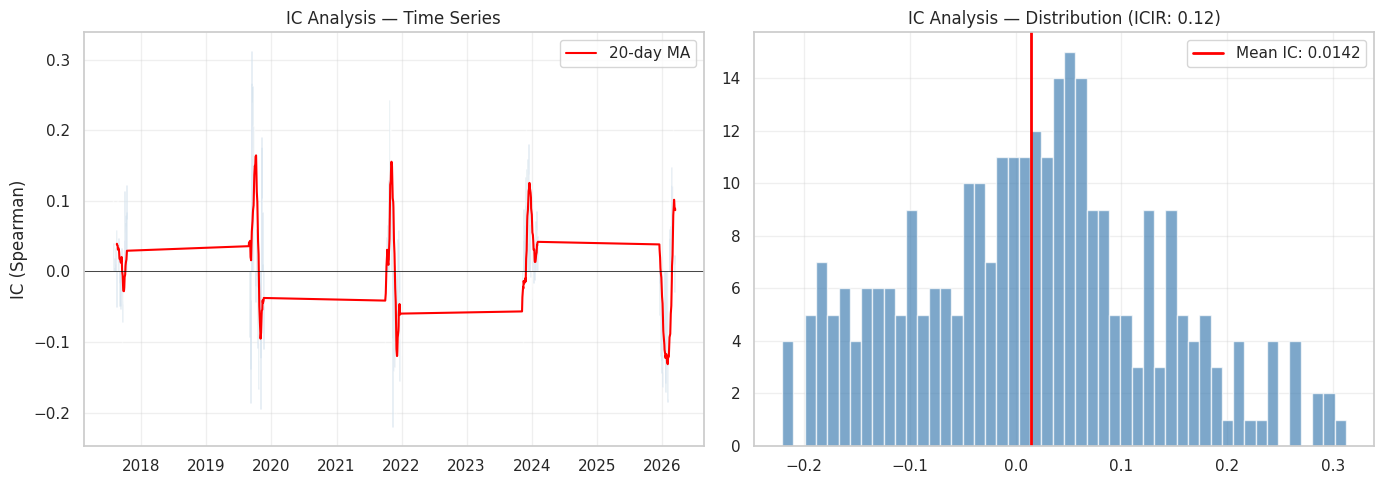

In [9]:
ic_series = calc_ic_series(predictions)
print(f"Mean IC:  {ic_series.mean():.4f}")
print(f"IC Std:   {ic_series.std():.4f}")
print(f"ICIR:     {ic_series.mean() / ic_series.std():.4f}")
print(f"IC > 0:   {(ic_series > 0).mean():.1%}")

plot_ic_analysis(ic_series)
plt.savefig("../output/equity_ic_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 分层回测（Quantile Analysis）

按预测值分 5 组，如果模型有效，Q5（最高预测值）应该收益最高，Q1 最低，呈单调递增。

Annualized mean return by quintile:
quantile
1    13.10%
2   108.89%
3    85.11%
4   -42.18%
5   116.05%

Q5 - Q1 spread: 102.95% annualized


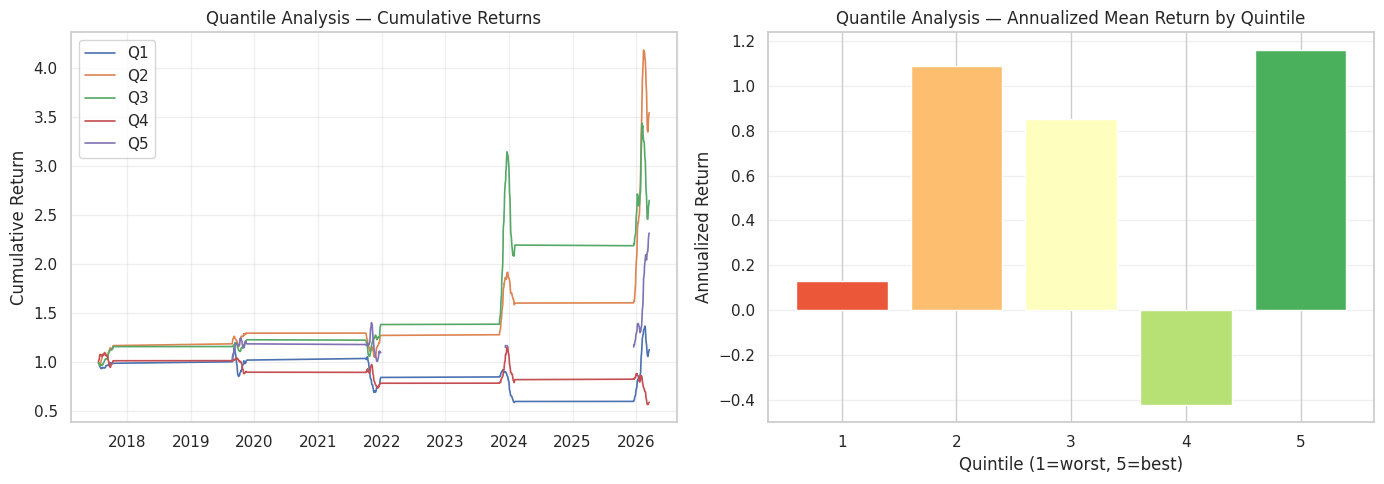

In [10]:
q_returns = quantile_analysis(predictions, n_groups=5)
print("Annualized mean return by quintile:")
print((q_returns.mean() * 252).to_string(float_format="{:.2%}".format))
print(f"\nQ5 - Q1 spread: {(q_returns[5].mean() - q_returns[1].mean()) * 252:.2%} annualized")

plot_quantile_returns(q_returns)
plt.savefig("../output/equity_quantile_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. 回测 — Top 10 / 20 / 30 对比

同时看多个 top-N，判断信号稳定性：
- 如果只有 top-5 好而 top-20 差 → 排序头部噪音，不可靠
- 如果 top-5/10/20 都有超额 → 信号有区分力

In [11]:
# Compute daily returns for backtest (raw returns, not residual)
daily_returns = compute_daily_returns(panel)

# SPY benchmark
spy_daily_ret = spy["close"].pct_change()

# Run backtest for multiple top-N values
for top_n in [10, 20, 30]:
    bt = backtest_topN(
        predictions=predictions,
        returns=daily_returns,
        top_n=top_n,
        rebalance_days=10,
        cost_bps=10,
    )
    
    spy_ret = spy_daily_ret.reindex(bt.index).fillna(0)
    strat = summary_metrics(bt["portfolio_return"])
    bench = summary_metrics(spy_ret)
    
    print(f"=== Top {top_n} (10-day rebalance, 10bps cost) ===")
    print(f"  Annual Return:    {strat['annual_return']:>8.2%}  (SPY: {bench['annual_return']:.2%})")
    print(f"  Sharpe:           {strat['sharpe_ratio']:>8.2f}  (SPY: {bench['sharpe_ratio']:.2f})")
    print(f"  Max Drawdown:     {strat['max_drawdown']:>8.2%}  (SPY: {bench['max_drawdown']:.2%})")
    print(f"  Excess Return:    {strat['annual_return'] - bench['annual_return']:>8.2%}")
    print(f"  Avg Turnover:     {bt['turnover'][bt['turnover'] > 0].mean():>8.1%}")
    print()

# Keep top-10 for detailed analysis
bt_results = backtest_topN(
    predictions=predictions,
    returns=daily_returns,
    top_n=10,
    rebalance_days=10,
    cost_bps=10,
)

=== Top 10 (10-day rebalance, 10bps cost) ===
  Annual Return:      41.19%  (SPY: 34.81%)
  Sharpe:               1.59  (SPY: 3.20)
  Max Drawdown:      -12.65%  (SPY: -4.77%)
  Excess Return:       6.38%
  Avg Turnover:        68.3%

=== Top 20 (10-day rebalance, 10bps cost) ===
  Annual Return:      21.51%  (SPY: 34.81%)
  Sharpe:               1.10  (SPY: 3.20)
  Max Drawdown:      -11.86%  (SPY: -4.77%)
  Excess Return:     -13.29%
  Avg Turnover:        66.2%

=== Top 30 (10-day rebalance, 10bps cost) ===
  Annual Return:      25.77%  (SPY: 34.81%)
  Sharpe:               1.46  (SPY: 3.20)
  Max Drawdown:      -10.15%  (SPY: -4.77%)
  Excess Return:      -9.04%
  Avg Turnover:        63.0%



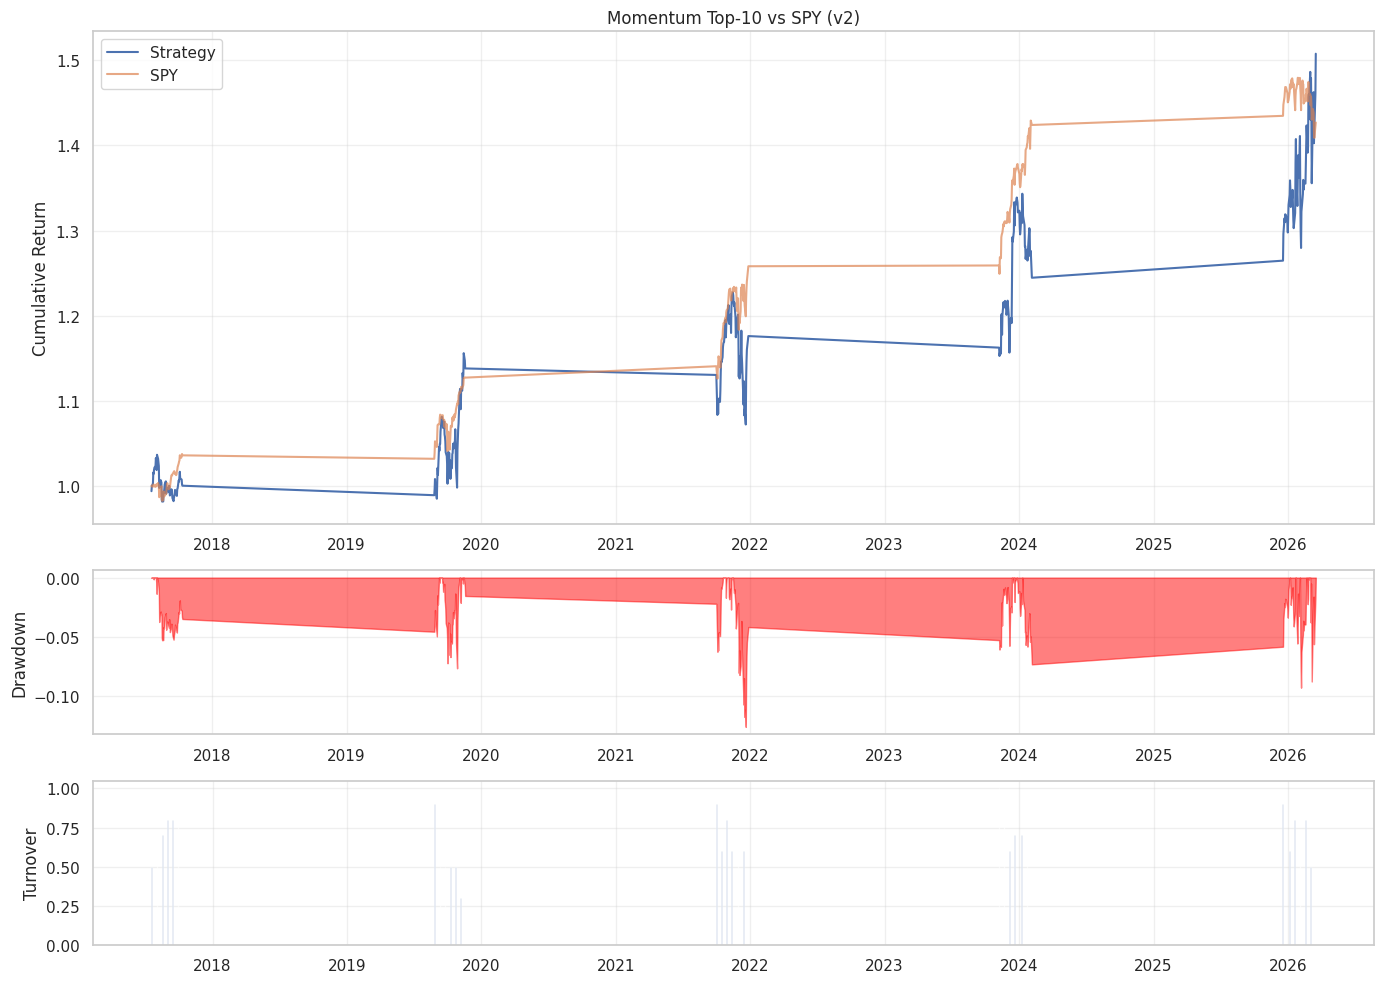

In [12]:
# Equity curve — Top 10 vs SPY
spy_ret_aligned = spy_daily_ret.reindex(bt_results.index).fillna(0)
plot_equity_curve(bt_results, spy_ret_aligned, title="Momentum Top-10 vs SPY (v2)")
plt.savefig("../output/equity_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Feature Importance

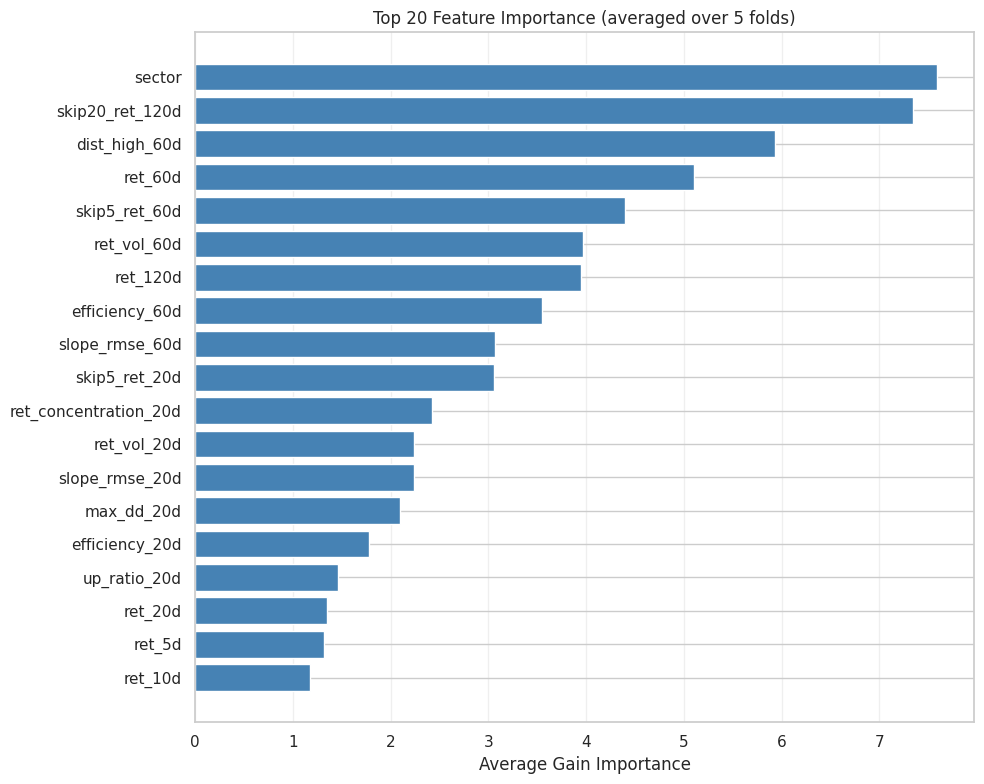

In [13]:
feature_names = features.columns.tolist()
plot_feature_importance(models, feature_names, top_n=20)
plt.savefig("../output/equity_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. 总结

**v2 改动**:
- 特征从 39 → 18，分 4 组（基础/skip/路径/风险调整动量）
- 去掉 sector neutralize + rank 双重变换
- 标签用原始残差收益
- 行业作为 categorical feature

**判断标准**:
- Mean IC > 0.02 且 ICIR > 0.5 → 信号有意义
- 分层回测 Q5 > Q4 > ... > Q1 → 模型有区分力
- Top 5/10/20 都有超额 → 信号稳定
- 策略年化收益 > SPY → pipeline 可用